# Projet REXIA -- Responsible and Explainable AI

## Partie 1/3 : Donnees tabulaires

Analyse du jeu de donnees RH anonymise. La variable cible `label` indique :
- **0** : l'employe n'a pas demissionne dans les 6 prochains mois
- **1** : l'employe a demissionne dans les 6 prochains mois

## 0. Imports et configuration

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -- Configuration globale des graphiques --
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
DATA_PATH = "../data/RH_dataset.csv"
CSV_SEPARATOR = ";"

LABEL_COL = "label"
LABEL_NAMES = {0: "Non-demission", 1: "Demission"}

## Fonctions utilitaires

In [3]:
def load_dataset(path: str, separator: str = ";") -> pd.DataFrame:
    """Charge le jeu de donnees CSV et retourne un DataFrame."""
    return pd.read_csv(path, sep=separator)

def display_summary_table(data: pd.DataFrame) -> pd.DataFrame:
    """Retourne un DataFrame recapitulatif : type, nb valeurs uniques, min, max, manquantes."""
    summary = pd.DataFrame({
        "Type": data.dtypes,
        "Valeurs uniques": data.nunique(),
        "Valeurs manquantes": data.isnull().sum(),
        "% manquantes": (data.isnull().sum() / len(data) * 100).round(2),
        "Exemple": data.iloc[0],
    })
    return summary

# Chargement du dataset

In [4]:
df = load_dataset(DATA_PATH, CSV_SEPARATOR)

print(f"Dimensions du jeu de donnees : {df.shape[0]} lignes, {df.shape[1]} colonnes\n")
df.head(10)

Dimensions du jeu de donnees : 23857 lignes, 14 colonnes



,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
0,Production,8.510000,7.900000,0.910000,0.970000,27,30,1,1,3199,Marié(e),0,32,0
1,Production,35.119999,22.690001,14.830000,16.299999,7,45,1,2,3861,Marié(e),1,1890,0
2,Production,25.299999,22.139999,17.309999,17.790001,28,49,1,2,4324,PACS,1,1847,0
3,Production,5.240000,5.100000,1.020000,1.750000,27,24,0,1,2641,Célibataire,0,2619,1
4,Production,35.919998,22.840000,8.050000,9.000000,7,46,1,2,5072,Marié(e),1,1963,0
5,Production,30.410000,29.049999,3.350000,4.290000,28,40,1,1,3510,PACS,1,2642,0
6,Commercial/Business,13.840000,32.410000,8.890000,42.509998,28,72,1,3,7223,Marié(e),1,318,0
7,Etudes & Technique,34.799999,22.790001,9.480000,10.580000,28,45,1,2,4132,Marié(e),1,2132,0
8,Etudes & Technique,80.220001,24.180000,8.090000,35.349998,28,65,0,2,4773,Divorcé(e),1,880,0
9,Etudes & Technique,5.190000,2.780000,1.420000,10.100000,28,42,0,2,4517,Union libre,1,676,0


In [4]:
!pip install imblearn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## 3. Apprentissage automatique

*(A completer lors de la prochaine seance.)*

Pistes prevues :
- Pre-traitement des donnees (encodage des variables categorielles, normalisation, gestion du desequilibre)
- Entrainement de modeles (regression logistique, arbre de decision, random forest, etc.)
- Evaluation avec des metriques adaptees au desequilibre (F1-score, AUC-ROC, matrice de confusion)
- Analyse de l'equite (fairness metrics) sur les groupes sensibles identifies en partie 2
- Explicabilite des predictions (SHAP, LIME)

### 3.1 Pipeline de prétraitement et gestion du déséquilibre

Nous utilisons un `ColumnTransformer` pour :
- Standardiser les variables numériques et ordinales/binaires (`StandardScaler`).
- Encoder les variables catégorielles nominales (`OneHotEncoder`).

Enfin, pour compenser la forte asymétrie de la variable cible (3.2% de démissions), nous appliquons la méthode **SMOTE** (Synthetic Minority Over-sampling Technique) sur le jeu d'entraînement.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE

# 0. Conservation de la dernière ligne par individu
# On trie d'abord par matricule et ancienneté pour s'assurer que la dernière ligne est la plus récente
df_unique = df.sort_values(by=['matricule', 'Ancienneté groupe (années)']).drop_duplicates(subset=['matricule'], keep='last')
print(f"Dimensions avant dédoublonnage : {df.shape}")
print(f"Dimensions après dédoublonnage : {df_unique.shape}\n")

# 1. Séparation train/test (stratifiée)
X = df_unique.drop(columns=[LABEL_COL])
y = df_unique[LABEL_COL]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Dimensions Train : {X_train.shape}, Test : {X_test.shape}")

# 2. Pipeline de prétraitement
# Etablissement a 35 catégories distinctes ; Famille d'emploi en a 8
categorical_features = ["Famille d'emploi", "Etablissement", 'Statut marital']
numerical_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

# 3. Application du prétraitement
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# 4. Gestion du déséquilibre avec SMOTE (sur le Train uniquement)
smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_preprocessed, y_train)

print(f"\nRépartition target AVANT SMOTE:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"Répartition target APRÈS SMOTE:\n{y_train_resampled.value_counts(normalize=True).round(3)}")
print(f"Nouvelles dimensions Train (après SMOTE) : X={X_train_resampled.shape}, y={y_train_resampled.shape}")

Dimensions avant dédoublonnage : (23857, 14)
Dimensions après dédoublonnage : (2676, 14)

Dimensions Train : (2140, 13), Test : (536, 13)

Répartition target AVANT SMOTE:
label
0    0.848
1    0.152
Name: proportion, dtype: float64
Répartition target APRÈS SMOTE:
label
0    0.5
1    0.5
Name: proportion, dtype: float64
Nouvelles dimensions Train (après SMOTE) : X=(3628, 62), y=(3628,)


In [6]:
X_test_preprocessed[:5]

array([[ 0.99468025,  3.66154445, -0.30934184, -0.61102605, -0.0843954 ,
         0.69869738, -0.87263871, -0.64606085, -1.05082609,  1.58038618,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ],
       [-1.09377733, -0.91515012,  0.22110782, -0.05903532,  0.088599  ,
         0.69869

### 3.2.1 Entraînement — Random Forest

Nous entraînons une **Random Forest** sur les données rééchantillonnées. C'est un bon point de départ : robuste au bruit, peu sensible aux hyperparamètres par défaut, et interprétable via l'importance des variables.

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
)

# --- Entraînement ---
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_resampled, y_train_resampled)
print("Entraînement terminé.")

Entraînement terminé.


### 3.2.2 Évaluation du modèle

On évalue sur le jeu de test (non touché par SMOTE ni par le fit du preprocesseur). Métriques prioritaires pour un problème déséquilibré : **F1-score**, **AUC-ROC**, et la **matrice de confusion**.

=== Rapport de classification ===
               precision    recall  f1-score   support

Non-demission       0.91      0.92      0.91       454
    Demission       0.53      0.51      0.52        82

     accuracy                           0.85       536
    macro avg       0.72      0.71      0.72       536
 weighted avg       0.85      0.85      0.85       536

AUC-ROC : 0.8281


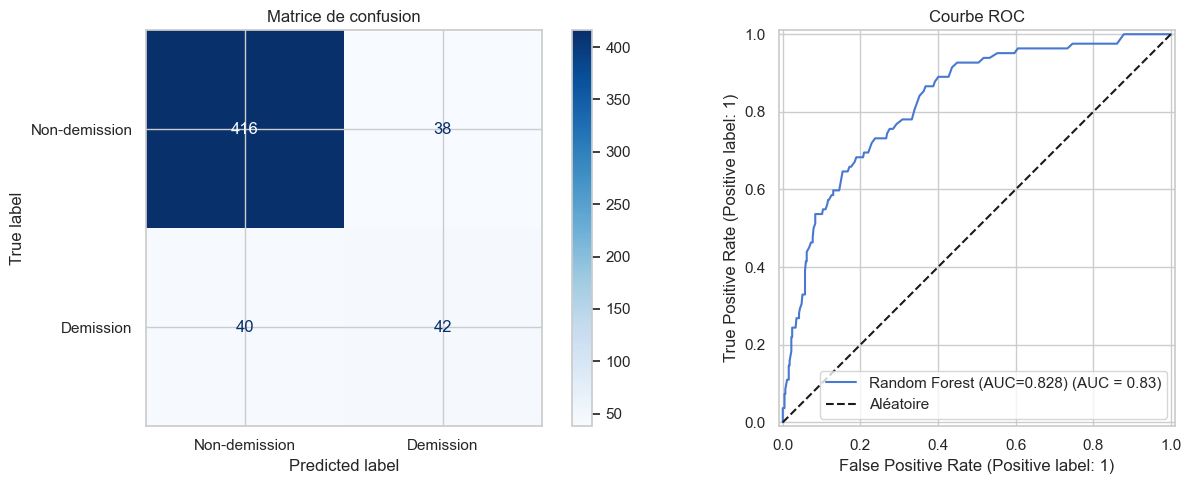

In [8]:
y_pred = rf.predict(X_test_preprocessed)
y_proba = rf.predict_proba(X_test_preprocessed)[:, 1]

# --- Rapport de classification ---
print("=== Rapport de classification ===")
print(classification_report(y_test, y_pred, target_names=list(LABEL_NAMES.values())))

# --- AUC-ROC ---
auc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC : {auc:.4f}")

# --- Matrice de confusion ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=list(LABEL_NAMES.values()),
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Matrice de confusion")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name=f"Random Forest (AUC={auc:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', label="Aléatoire")
axes[1].set_title("Courbe ROC")
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.2.3 Importance des variables

La Random Forest fournit nativement une importance des variables (basée sur la réduction d'impureté de Gini). Cela donne un premier aperçu des features les plus discriminantes.

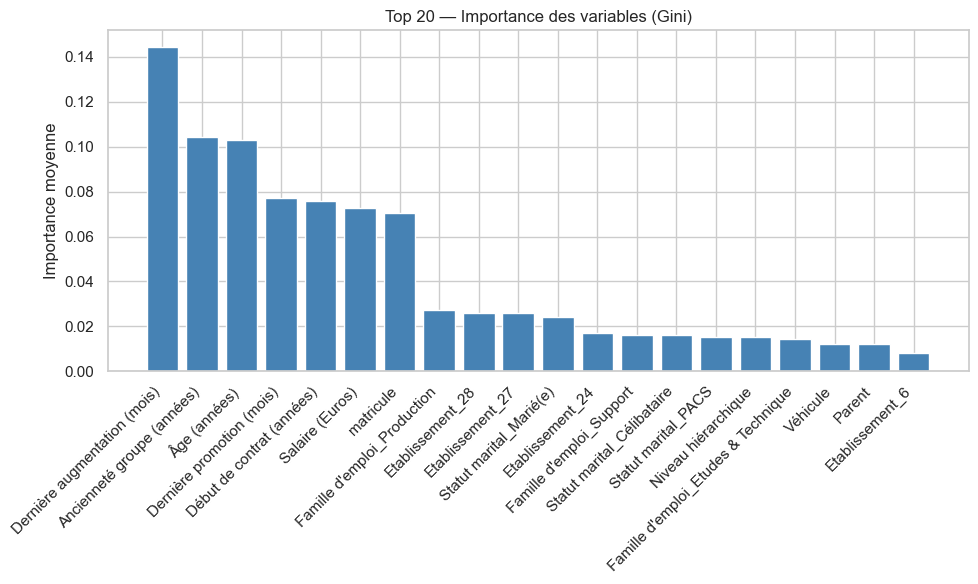

In [9]:
# Récupération des noms de features après OneHotEncoder
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(ohe_feature_names)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 20

plt.figure(figsize=(10, 6))
plt.bar(range(top_n), importances[indices[:top_n]], color="steelblue")
plt.xticks(range(top_n), [all_feature_names[i] for i in indices[:top_n]], rotation=45, ha='right')
plt.title(f"Top {top_n} — Importance des variables (Gini)")
plt.ylabel("Importance moyenne")
plt.tight_layout()
plt.show()

---
### 3.3 Régression Logistique

La **régression logistique** est un modèle linéaire de classification. Malgré sa simplicité, elle offre une bonne interprétabilité via les coefficients (odds-ratios) et constitue une baseline solide pour comparer les modèles plus complexes.

On l'entraîne ici avec régularisation L2 (par défaut) sur les données rééchantillonnées par SMOTE.

Entraînement terminé.

=== Rapport de classification — Régression Logistique ===
               precision    recall  f1-score   support

Non-demission       0.94      0.61      0.74       454
    Demission       0.26      0.78      0.40        82

     accuracy                           0.63       536
    macro avg       0.60      0.69      0.57       536
 weighted avg       0.84      0.63      0.69       536

AUC-ROC : 0.7499


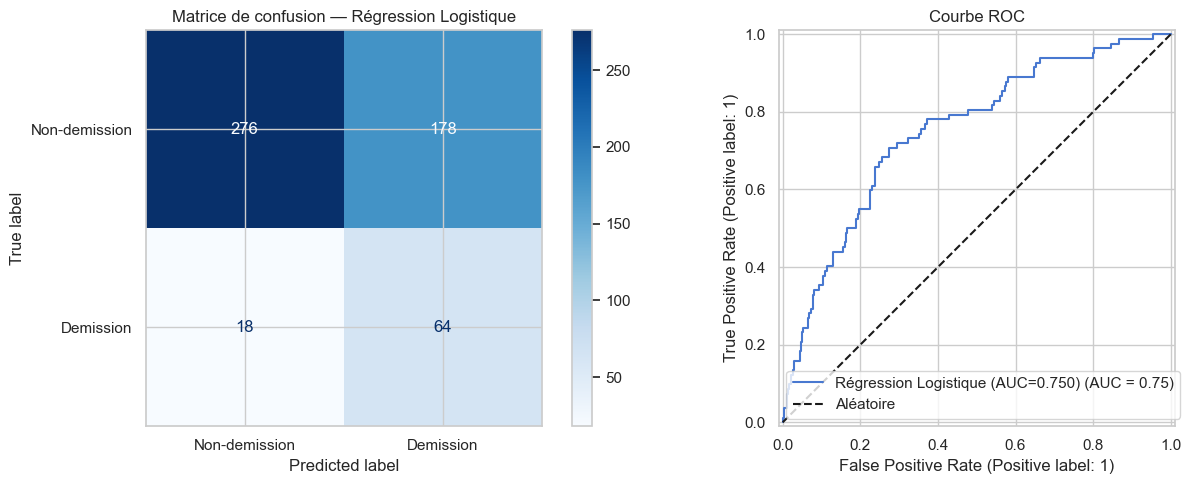

In [10]:
from sklearn.linear_model import LogisticRegression

# --- Entraînement ---
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
lr.fit(X_train_resampled, y_train_resampled)
print("Entraînement terminé.")

# --- Évaluation ---
y_pred_lr = lr.predict(X_test_preprocessed)
y_proba_lr = lr.predict_proba(X_test_preprocessed)[:, 1]

print("\n=== Rapport de classification — Régression Logistique ===")
print(classification_report(y_test, y_pred_lr, target_names=list(LABEL_NAMES.values())))

auc_lr = roc_auc_score(y_test, y_proba_lr)
print(f"AUC-ROC : {auc_lr:.4f}")

# --- Visualisations ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=list(LABEL_NAMES.values()),
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Matrice de confusion — Régression Logistique")

RocCurveDisplay.from_predictions(y_test, y_proba_lr, ax=axes[1],
                                  name=f"Régression Logistique (AUC={auc_lr:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', label="Aléatoire")
axes[1].set_title("Courbe ROC")
axes[1].legend()

plt.tight_layout()
plt.show()

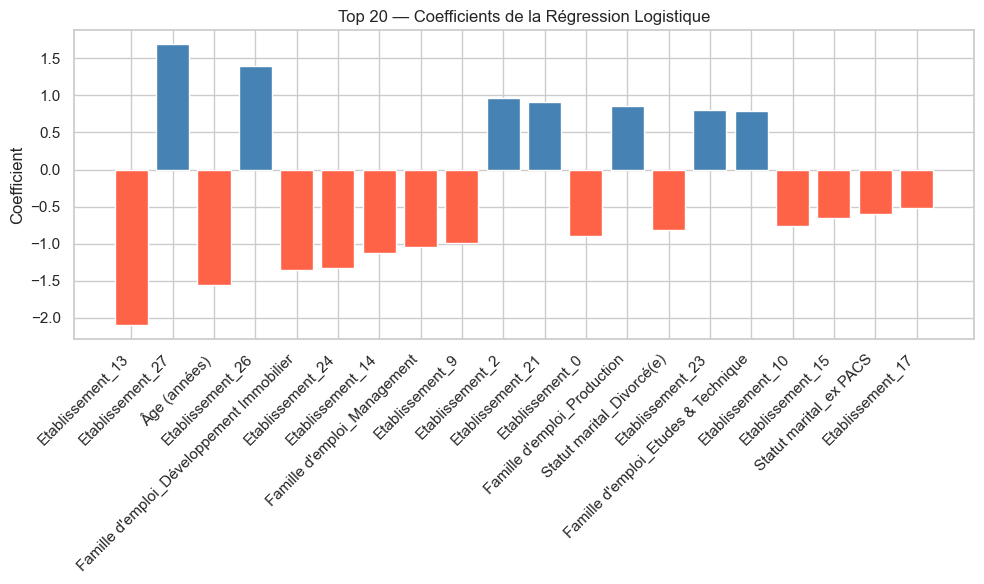

In [11]:
# --- Coefficients les plus importants ---
coefs = lr.coef_[0]
indices_lr = np.argsort(np.abs(coefs))[::-1]
top_n = 20

plt.figure(figsize=(10, 6))
colors = ["tomato" if coefs[i] < 0 else "steelblue" for i in indices_lr[:top_n]]
plt.bar(range(top_n), coefs[indices_lr[:top_n]], color=colors)
plt.xticks(range(top_n), [all_feature_names[i] for i in indices_lr[:top_n]], rotation=45, ha='right')
plt.title(f"Top {top_n} — Coefficients de la Régression Logistique")
plt.ylabel("Coefficient")
plt.tight_layout()
plt.show()

In [13]:
[all_feature_names[i] for i in indices_lr[:top_n]]

['Etablissement_13',
 'Etablissement_27',
 'Âge (années)',
 'Etablissement_26',
 "Famille d'emploi_Développement Immobilier",
 'Etablissement_24',
 'Etablissement_14',
 "Famille d'emploi_Management",
 'Etablissement_9',
 'Etablissement_2',
 'Etablissement_21',
 'Etablissement_0',
 "Famille d'emploi_Production",
 'Statut marital_Divorcé(e)',
 'Etablissement_23',
 "Famille d'emploi_Etudes & Technique",
 'Etablissement_10',
 'Etablissement_15',
 'Statut marital_ex PACS',
 'Etablissement_17']

---
### 3.4 Generalized Additive Model (GAM)

Un **GAM** (Modèle Additif Généralisé) étend la régression logistique en remplaçant les termes linéaires par des fonctions lisses non-linéaires de chaque feature :

$$\log\frac{p}{1-p} = \beta_0 + f_1(x_1) + f_2(x_2) + \cdots + f_p(x_p)$$

Il conserve ainsi l'**interprétabilité par variable** (shape functions) tout en capturant des effets non-linéaires.

On utilise la librairie **`pygam`** avec un `LogisticGAM`.

In [12]:
!pip install pygam -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from pygam import LogisticGAM, s, f

# Construction des termes : spline pour chaque feature numérique, facteur pour OHE
n_num = len(numerical_features)
n_cat_ohe = X_train_resampled.shape[1] - n_num

terms = s(0)
for i in range(1, n_num):
    terms += s(i)
for i in range(n_num, n_num + n_cat_ohe):
    terms += f(i)

# --- Entraînement avec recherche automatique du lissage (gridsearch) ---
gam = LogisticGAM(terms).gridsearch(X_train_resampled, y_train_resampled)
print("Entraînement GAM terminé.")

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--


In [ ]:
y_pred_gam = (gam.predict_proba(X_test_preprocessed) >= 0.5).astype(int)
y_proba_gam = gam.predict_proba(X_test_preprocessed)

print("=== Rapport de classification — GAM ===")
print(classification_report(y_test, y_pred_gam, target_names=list(LABEL_NAMES.values())))

auc_gam = roc_auc_score(y_test, y_proba_gam)
print(f"AUC-ROC : {auc_gam:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_gam,
    display_labels=list(LABEL_NAMES.values()),
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Matrice de confusion — GAM")

RocCurveDisplay.from_predictions(y_test, y_proba_gam, ax=axes[1],
                                  name=f"GAM (AUC={auc_gam:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', label="Aléatoire")
axes[1].set_title("Courbe ROC")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# --- Shape functions des variables numériques (top 6) ---
# Les shape functions montrent l'effet partiel f_i(x_i) de chaque variable sur le log-odds
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    XX = gam.generate_X_grid(term=idx)
    pdep, confi = gam.partial_dependence(term=idx, X=XX, width=0.95)
    ax.plot(XX[:, idx], pdep, color="steelblue", lw=2)
    ax.fill_between(XX[:, idx], confi[:, 0], confi[:, 1], alpha=0.2, color="steelblue")
    ax.axhline(0, color='k', linestyle='--', lw=0.8)
    ax.set_title(f"Shape function : {numerical_features[idx]}", fontsize=10)
    ax.set_xlabel(numerical_features[idx])
    ax.set_ylabel("Effet partiel (log-odds)")

plt.suptitle("GAM — Shape functions des variables numériques (top 6)", fontsize=13)
plt.tight_layout()
plt.show()

### 3.5 Comparaison des modèles

| Modèle | AUC-ROC |
|---|---|
| Random Forest | `auc_rf` |
| Régression Logistique | `auc_lr` |
| GAM | `auc_gam` |

In [ ]:
results = pd.DataFrame({
    "Modèle": ["Random Forest", "Régression Logistique", "GAM"],
    "AUC-ROC": [auc, auc_lr, auc_gam]
}).sort_values("AUC-ROC", ascending=False).reset_index(drop=True)

print(results.to_string(index=False))

plt.figure(figsize=(7, 4))
plt.barh(results["Modèle"], results["AUC-ROC"], color=["steelblue", "seagreen", "tomato"])
plt.xlim(0.5, 1.0)
plt.xlabel("AUC-ROC")
plt.title("Comparaison des modèles — AUC-ROC")
for i, v in enumerate(results["AUC-ROC"]):
    plt.text(v + 0.002, i, f"{v:.4f}", va='center')
plt.tight_layout()
plt.show()

---
## 4. Explication post-hoc — LIME

**LIME** (Local Interpretable Model-agnostic Explanations) explique les prédictions d'un modèle *au niveau local* : pour chaque individu, il ajuste un modèle linéaire simple autour de la prédiction et identifie les variables qui ont pesé le plus dans la décision.

Contrairement à l'importance globale des variables (Gini pour la RF, coefficients pour la LR), LIME permet de comprendre **pourquoi un individu précis** a été classé comme démissionnaire ou non.

In [16]:
!pip install lime --user

  Using cached lime-0.2.0.1-py3-none-any.whl
  Using cached scikit_image-0.26.0-cp312-cp312-win_amd64.whl.metadata (15 kB)
  Using cached imageio-2.37.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
Using cached scikit_image-0.26.0-cp312-cp312-win_amd64.whl (11.9 MB)
Using cached imageio-2.37.3-py3-none-any.whl (317 kB)
Using cached lazy_loader-0.5-py3-none-any.whl (8.0 kB)



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 4.1 LIME — Random Forest

On explique quelques prédictions de la Random Forest avec LIME. On sélectionne un vrai positif (démissionnaire correctement identifié) et un faux négatif (démissionnaire manqué) pour comparer les explications.

Nombre de vrais positifs (TP) : 42
Nombre de faux négatifs (FN) : 40

=== Explication LIME — Vrai Positif (Random Forest) ===


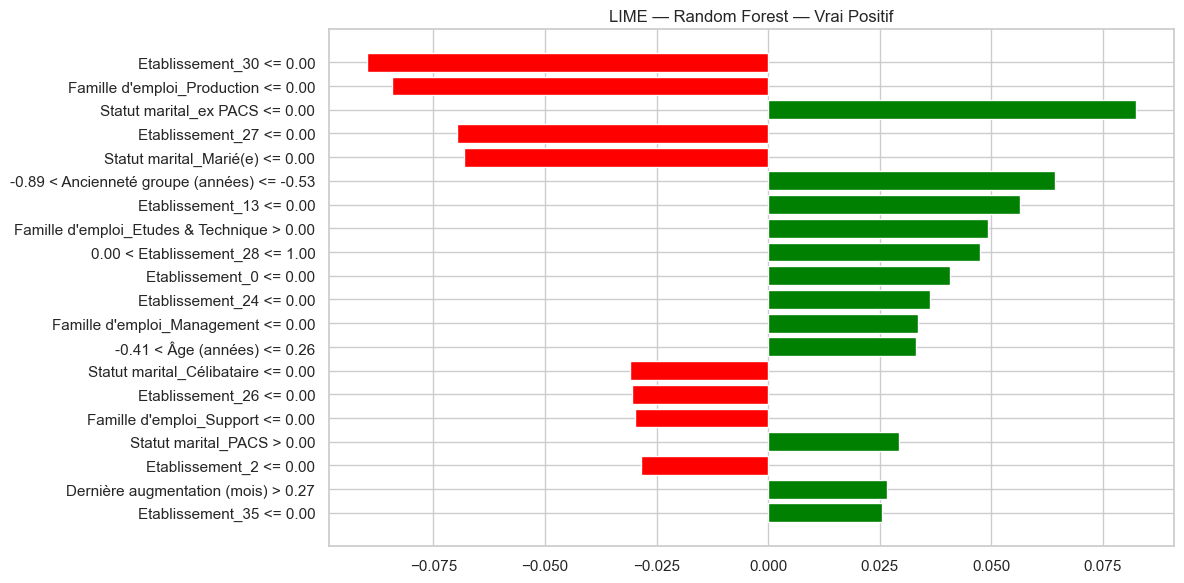


=== Explication LIME — Faux Négatif (Random Forest) ===


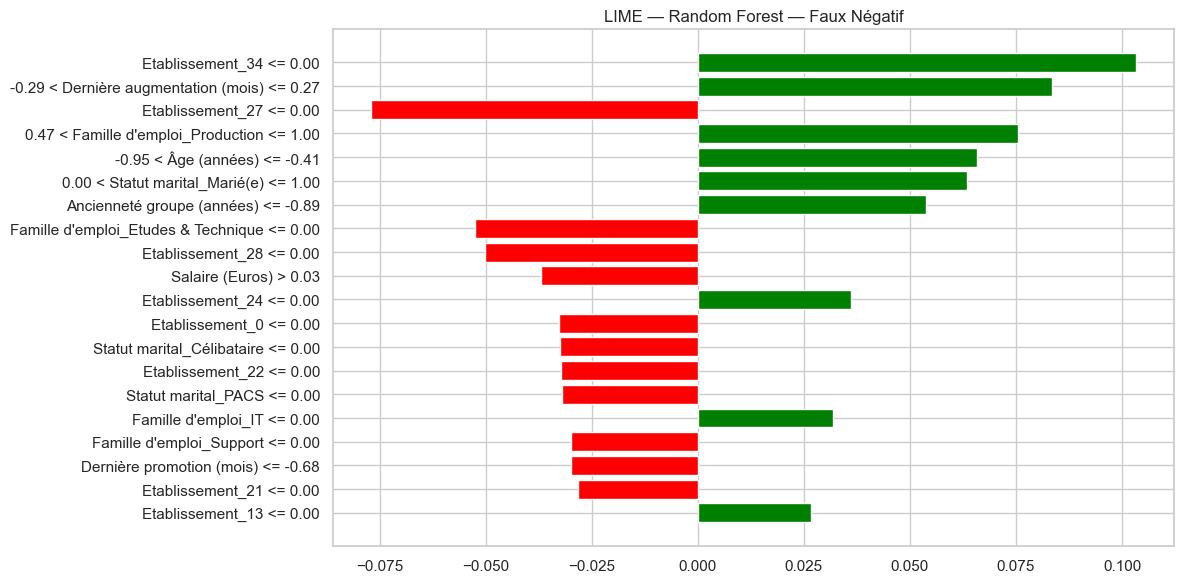


Top 20 features (LIME agrégé sur train) — Random Forest :
['Âge (années)', 'Ancienneté groupe (années)', "Famille d'emploi_Production", 'Etablissement_27', 'Statut marital_Marié(e)', 'Dernière augmentation (mois)', 'Etablissement_28', "Famille d'emploi_Etudes & Technique", 'Etablissement_24', 'Statut marital_Célibataire', 'Etablissement_30', 'Statut marital_PACS', 'Etablissement_36', 'Etablissement_13', 'Etablissement_33', 'Etablissement_35', "Famille d'emploi_Support", 'Etablissement_34', 'Statut marital_ex PACS', 'Etablissement_21']


In [23]:
import lime
import lime.lime_tabular

# Création de l'explainer LIME
explainer_rf = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_resampled,
    feature_names=all_feature_names,
    class_names=list(LABEL_NAMES.values()),
    mode='classification',
    random_state=RANDOM_STATE
)

# --- Sélection d'un vrai positif (TP) et d'un faux négatif (FN) ---
tp_indices = np.where((y_test.values == 1) & (y_pred == 1))[0]
fn_indices = np.where((y_test.values == 1) & (y_pred == 0))[0]

print(f"Nombre de vrais positifs (TP) : {len(tp_indices)}")
print(f"Nombre de faux négatifs (FN) : {len(fn_indices)}")

# Explication d'un vrai positif
if len(tp_indices) > 0:
    idx_tp = tp_indices[0]
    exp_tp = explainer_rf.explain_instance(
        X_test_preprocessed[idx_tp],
        rf.predict_proba,
        num_features=20
    )
    print("\n=== Explication LIME — Vrai Positif (Random Forest) ===")
    fig = exp_tp.as_pyplot_figure()
    plt.title("LIME — Random Forest — Vrai Positif")
    plt.tight_layout()
    plt.show()

# Explication d'un faux négatif
if len(fn_indices) > 0:
    idx_fn = fn_indices[0]
    exp_fn = explainer_rf.explain_instance(
        X_test_preprocessed[idx_fn],
        rf.predict_proba,
        num_features=20
    )
    print("\n=== Explication LIME — Faux Négatif (Random Forest) ===")
    fig = exp_fn.as_pyplot_figure()
    plt.title("LIME — Random Forest — Faux Négatif")
    plt.tight_layout()
    plt.show()

# --- Agrégation globale LIME — Random Forest ---
# On échantillonne sur X_train_preprocessed (et non X_test) pour éviter tout
# data leakage : la sélection de features ne doit pas être informée par le jeu de test.
N_LIME_SAMPLES = 100
rng = np.random.default_rng(RANDOM_STATE)
sample_idx_rf = rng.choice(len(X_train_preprocessed), size=N_LIME_SAMPLES, replace=False)

lime_weights_rf = np.zeros(len(all_feature_names))
for i in sample_idx_rf:
    exp = explainer_rf.explain_instance(
        X_train_preprocessed[i], rf.predict_proba, num_features=len(all_feature_names)
    )
    for feat_idx, weight in exp.local_exp[1]:
        lime_weights_rf[feat_idx] += abs(weight)
lime_weights_rf /= N_LIME_SAMPLES

top_20_rf_indices = np.argsort(lime_weights_rf)[::-1][:20]
top_features_rf = [all_feature_names[i] for i in top_20_rf_indices]
print("\nTop 20 features (LIME agrégé sur train) — Random Forest :")
print(top_features_rf)

### 4.2 LIME — Régression Logistique

On applique la même démarche LIME sur la régression logistique pour comparer les explications locales entre les deux modèles.

Nombre de vrais positifs (TP) : 64
Nombre de faux négatifs (FN) : 18

=== Explication LIME — Vrai Positif (Régression Logistique) ===


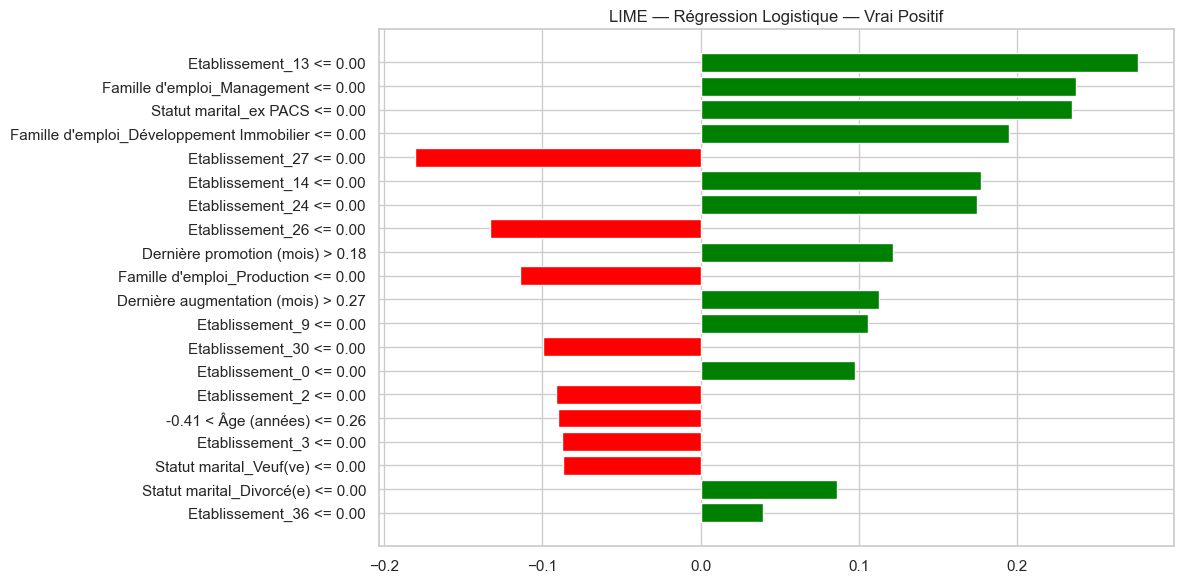


=== Explication LIME — Faux Négatif (Régression Logistique) ===


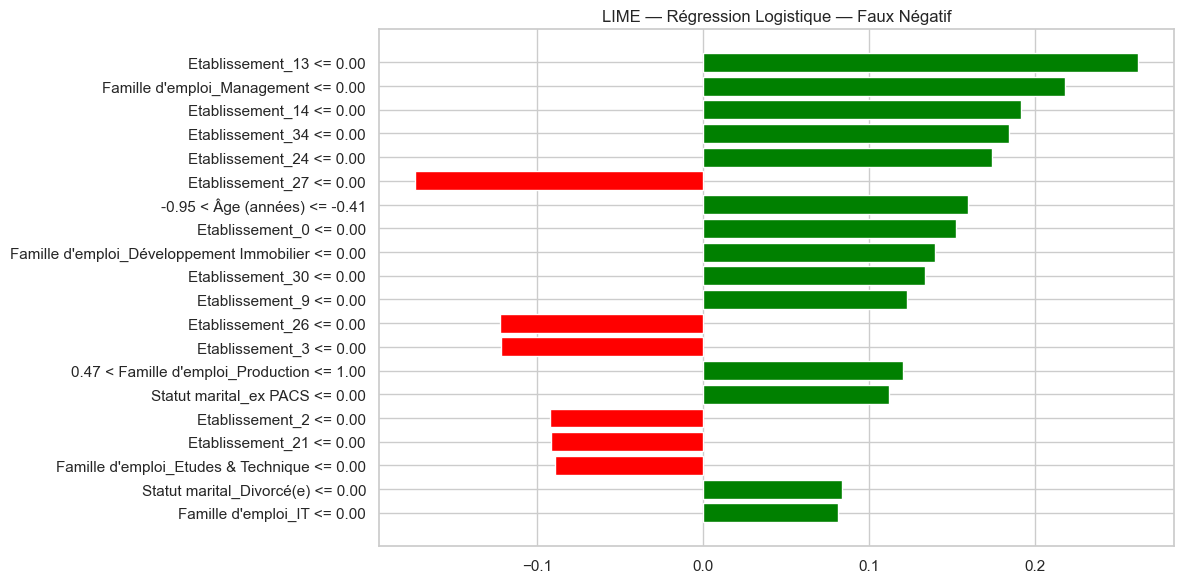


Top 20 features (LIME agrégé sur train) — Régression Logistique :
['Âge (années)', 'Etablissement_13', 'Etablissement_27', 'Etablissement_14', "Famille d'emploi_Développement Immobilier", 'Etablissement_24', "Famille d'emploi_Management", 'Etablissement_26', "Famille d'emploi_Production", 'Etablissement_9', 'Etablissement_0', 'Etablissement_2', "Famille d'emploi_Etudes & Technique", 'Statut marital_Divorcé(e)', 'Statut marital_ex PACS', 'Etablissement_10', 'Etablissement_21', 'Etablissement_23', 'Salaire (Euros)', 'Etablissement_34']


In [24]:
# Création de l'explainer LIME pour la Régression Logistique
explainer_lr = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_resampled,
    feature_names=all_feature_names,
    class_names=list(LABEL_NAMES.values()),
    mode='classification',
    random_state=RANDOM_STATE
)

# --- Sélection d'un vrai positif et d'un faux négatif pour la LR ---
tp_indices_lr = np.where((y_test.values == 1) & (y_pred_lr == 1))[0]
fn_indices_lr = np.where((y_test.values == 1) & (y_pred_lr == 0))[0]

print(f"Nombre de vrais positifs (TP) : {len(tp_indices_lr)}")
print(f"Nombre de faux négatifs (FN) : {len(fn_indices_lr)}")

# Explication d'un vrai positif
if len(tp_indices_lr) > 0:
    idx_tp_lr = tp_indices_lr[0]
    exp_tp_lr = explainer_lr.explain_instance(
        X_test_preprocessed[idx_tp_lr],
        lr.predict_proba,
        num_features=20
    )
    print("\n=== Explication LIME — Vrai Positif (Régression Logistique) ===")
    fig = exp_tp_lr.as_pyplot_figure()
    plt.title("LIME — Régression Logistique — Vrai Positif")
    plt.tight_layout()
    plt.show()

# Explication d'un faux négatif
if len(fn_indices_lr) > 0:
    idx_fn_lr = fn_indices_lr[0]
    exp_fn_lr = explainer_lr.explain_instance(
        X_test_preprocessed[idx_fn_lr],
        lr.predict_proba,
        num_features=20
    )
    print("\n=== Explication LIME — Faux Négatif (Régression Logistique) ===")
    fig = exp_fn_lr.as_pyplot_figure()
    plt.title("LIME — Régression Logistique — Faux Négatif")
    plt.tight_layout()
    plt.show()

# --- Agrégation globale LIME — Régression Logistique ---
# Même principe : on échantillonne sur X_train_preprocessed pour éviter le data leakage.
# Même seed → même sous-ensemble d'individus que pour la RF (comparaison équitable).
rng_lr = np.random.default_rng(RANDOM_STATE)
sample_idx_lr = rng_lr.choice(len(X_train_preprocessed), size=N_LIME_SAMPLES, replace=False)

lime_weights_lr = np.zeros(len(all_feature_names))
for i in sample_idx_lr:
    exp = explainer_lr.explain_instance(
        X_train_preprocessed[i], lr.predict_proba, num_features=len(all_feature_names)
    )
    for feat_idx, weight in exp.local_exp[1]:
        lime_weights_lr[feat_idx] += abs(weight)
lime_weights_lr /= N_LIME_SAMPLES

top_20_lr_indices = np.argsort(lime_weights_lr)[::-1][:20]
top_features_lr = [all_feature_names[i] for i in top_20_lr_indices]
print("\nTop 20 features (LIME agrégé sur train) — Régression Logistique :")
print(top_features_lr)

### 4.3 Réduction des colonnes à partir des explications

Les analyses LIME et les mesures d'importance des variables (Gini pour la RF, coefficients pour la LR) convergent vers un sous-ensemble restreint de variables influentes. On réduit le jeu de données à ces variables pour chaque modèle afin de :
1. Simplifier le modèle (meilleure interprétabilité).
2. Réduire le risque de sur-apprentissage.
3. Vérifier si la performance se maintient avec moins de features.

In [25]:
# --- Fusion des importances LIME des deux modèles ---
# On normalise chaque vecteur de poids (norme L1) puis on calcule la moyenne.
# Les features consensuelles (importantes pour RF ET LR) remontent naturellement ;
# c'est plus robuste qu'une intersection pure (qui peut donner trop peu de features)
# et plus fin qu'une union (qui ne hiérarchise pas).

lime_rf_norm = lime_weights_rf / (lime_weights_rf.sum() + 1e-12)
lime_lr_norm = lime_weights_lr / (lime_weights_lr.sum() + 1e-12)
lime_consensus = (lime_rf_norm + lime_lr_norm) / 2

top_20_consensus = np.argsort(lime_consensus)[::-1][:20]
top_features_consensus = [all_feature_names[i] for i in top_20_consensus]

print("Top 20 features — score LIME consensus (RF + LR normalisés) :")
for rank, feat in enumerate(top_features_consensus, 1):
    rf_rank  = list(top_features_rf).index(feat) + 1  if feat in top_features_rf  else "—"
    lr_rank  = list(top_features_lr).index(feat) + 1  if feat in top_features_lr  else "—"
    print(f"  {rank:2d}. {feat:<45s}  (RF: {str(rf_rank):>3s}  LR: {str(lr_rank):>3s})")

print(f"\nIntersection RF ∩ LR          : {len(set(top_features_rf) & set(top_features_lr))} features")
print(f"Features consensus retenues   : {len(top_features_consensus)} features")

# Jeu de données réduit unique, utilisé pour les deux modèles
indices_consensus = [all_feature_names.index(f) for f in top_features_consensus]
X_train_reduced = X_train_resampled[:, indices_consensus]
X_test_reduced  = X_test_preprocessed[:, indices_consensus]

print(f"\nDimensions X_train réduit : {X_train_reduced.shape}")
print(f"Dimensions X_test  réduit : {X_test_reduced.shape}")

Top 20 features — score LIME consensus (RF + LR normalisés) :
   1. Âge (années)                                   (RF:   1  LR:   1)
   2. Etablissement_27                               (RF:   4  LR:   3)
   3. Etablissement_13                               (RF:  14  LR:   2)
   4. Famille d'emploi_Production                    (RF:   3  LR:   9)
   5. Ancienneté groupe (années)                     (RF:   2  LR:   —)
   6. Etablissement_24                               (RF:   9  LR:   6)
   7. Statut marital_Marié(e)                        (RF:   5  LR:   —)
   8. Famille d'emploi_Etudes & Technique            (RF:   8  LR:  13)
   9. Etablissement_14                               (RF:   —  LR:   4)
  10. Dernière augmentation (mois)                   (RF:   6  LR:   —)
  11. Famille d'emploi_Management                    (RF:   —  LR:   7)
  12. Famille d'emploi_Développement Immobilier      (RF:   —  LR:   5)
  13. Etablissement_26                               (RF:   —  LR:   8)
  

---
## 5. Apprentissage automatique — Modèles réduits

On réentraîne les deux modèles sur le **jeu de données réduit commun** (`top_features_consensus`) obtenu en section 4.3 par fusion des scores LIME normalisés de la RF et de la LR.

### 5.1 Random Forest — Modèle réduit (20 features consensus)

=== Rapport de classification — Random Forest (réduit consensus) ===
               precision    recall  f1-score   support

Non-demission       0.90      0.87      0.88       454
    Demission       0.39      0.45      0.42        82

     accuracy                           0.81       536
    macro avg       0.64      0.66      0.65       536
 weighted avg       0.82      0.81      0.81       536

AUC-ROC : 0.7681  (complet : 0.8281)


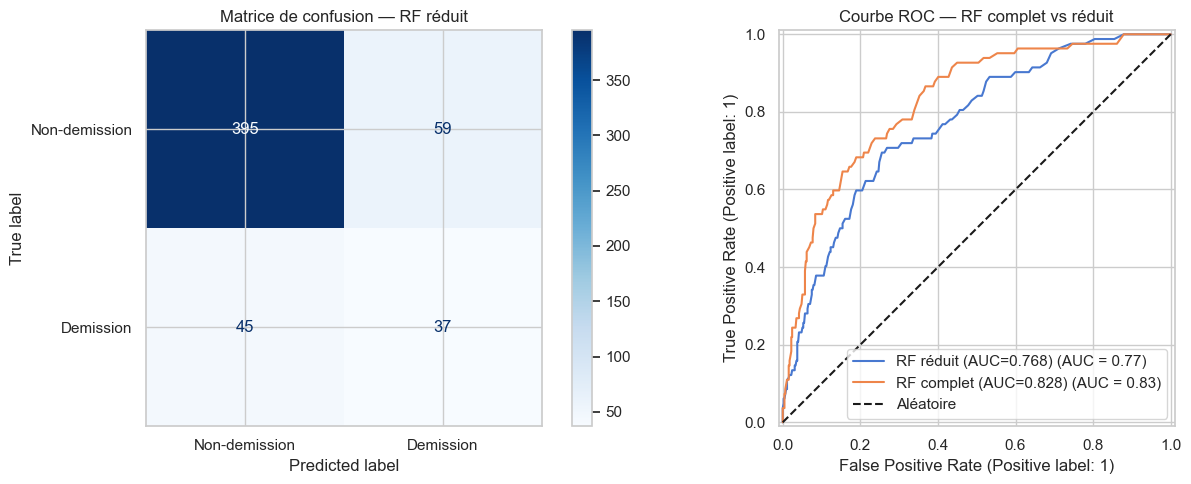

In [26]:
# --- Entraînement Random Forest réduit (features consensus) ---
rf_reduced = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_reduced.fit(X_train_reduced, y_train_resampled)

# --- Évaluation ---
y_pred_rf_red = rf_reduced.predict(X_test_reduced)
y_proba_rf_red = rf_reduced.predict_proba(X_test_reduced)[:, 1]

print("=== Rapport de classification — Random Forest (réduit consensus) ===")
print(classification_report(y_test, y_pred_rf_red, target_names=list(LABEL_NAMES.values())))

auc_rf_red = roc_auc_score(y_test, y_proba_rf_red)
print(f"AUC-ROC : {auc_rf_red:.4f}  (complet : {auc:.4f})")

# --- Visualisations ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf_red,
    display_labels=list(LABEL_NAMES.values()),
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Matrice de confusion — RF réduit")

RocCurveDisplay.from_predictions(y_test, y_proba_rf_red, ax=axes[1],
                                  name=f"RF réduit (AUC={auc_rf_red:.3f})")
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1],
                                  name=f"RF complet (AUC={auc:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', label="Aléatoire")
axes[1].set_title("Courbe ROC — RF complet vs réduit")
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.2 Régression Logistique — Modèle réduit (20 features consensus)

=== Rapport de classification — Régression Logistique (réduit consensus) ===
               precision    recall  f1-score   support

Non-demission       0.93      0.61      0.74       454
    Demission       0.26      0.76      0.39        82

     accuracy                           0.63       536
    macro avg       0.60      0.68      0.56       536
 weighted avg       0.83      0.63      0.68       536

AUC-ROC : 0.7458  (complet : 0.7499)


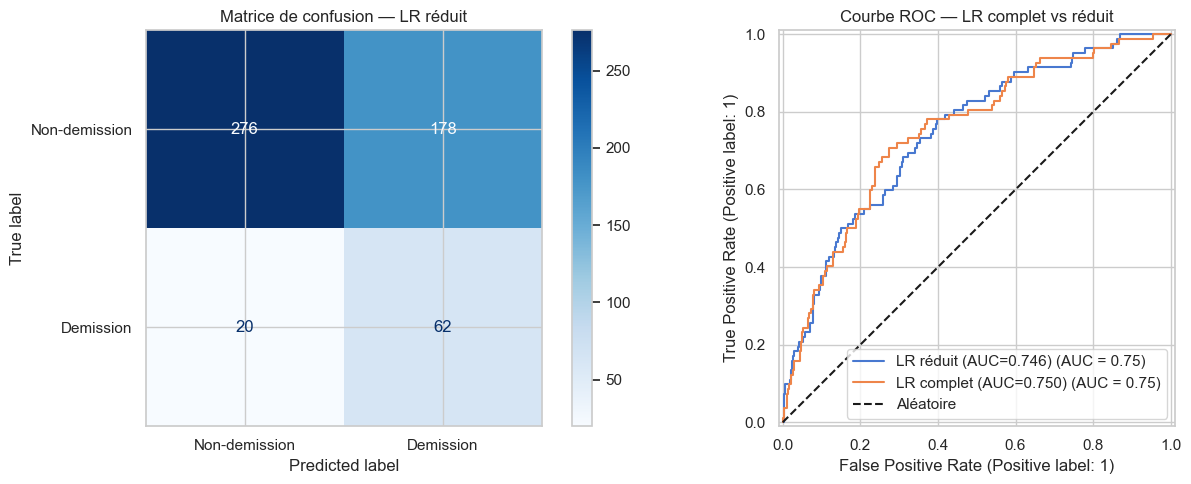

In [27]:
# --- Entraînement Régression Logistique réduite (features consensus) ---
lr_reduced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
lr_reduced.fit(X_train_reduced, y_train_resampled)

# --- Évaluation ---
y_pred_lr_red = lr_reduced.predict(X_test_reduced)
y_proba_lr_red = lr_reduced.predict_proba(X_test_reduced)[:, 1]

print("=== Rapport de classification — Régression Logistique (réduit consensus) ===")
print(classification_report(y_test, y_pred_lr_red, target_names=list(LABEL_NAMES.values())))

auc_lr_red = roc_auc_score(y_test, y_proba_lr_red)
print(f"AUC-ROC : {auc_lr_red:.4f}  (complet : {auc_lr:.4f})")

# --- Visualisations ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr_red,
    display_labels=list(LABEL_NAMES.values()),
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Matrice de confusion — LR réduit")

RocCurveDisplay.from_predictions(y_test, y_proba_lr_red, ax=axes[1],
                                  name=f"LR réduit (AUC={auc_lr_red:.3f})")
RocCurveDisplay.from_predictions(y_test, y_proba_lr, ax=axes[1],
                                  name=f"LR complet (AUC={auc_lr:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', label="Aléatoire")
axes[1].set_title("Courbe ROC — LR complet vs réduit")
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.3 Comparaison — Modèles complets vs réduits

                                         Modèle  Nb features  AUC-ROC
                        Random Forest (complet)           62 0.828073
        Random Forest (réduit — consensus LIME)           20 0.768064
                Régression Logistique (complet)           62 0.749866
Régression Logistique (réduit — consensus LIME)           20 0.745783


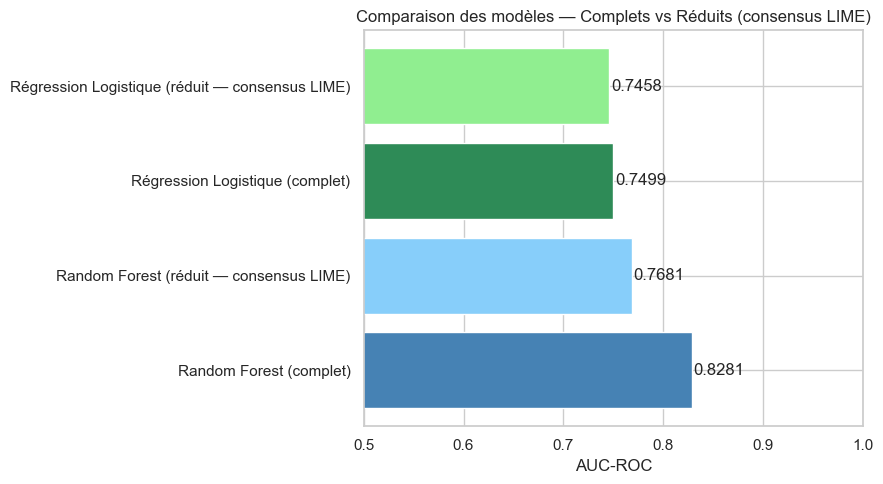

In [28]:
results_comparison = pd.DataFrame({
    "Modèle": [
        "Random Forest (complet)",
        "Random Forest (réduit — consensus LIME)",
        "Régression Logistique (complet)",
        "Régression Logistique (réduit — consensus LIME)"
    ],
    "Nb features": [
        len(all_feature_names),
        len(top_features_consensus),
        len(all_feature_names),
        len(top_features_consensus)
    ],
    "AUC-ROC": [auc, auc_rf_red, auc_lr, auc_lr_red]
})

print(results_comparison.to_string(index=False))

plt.figure(figsize=(9, 5))
colors_comp = ["steelblue", "lightskyblue", "seagreen", "lightgreen"]
plt.barh(results_comparison["Modèle"], results_comparison["AUC-ROC"], color=colors_comp)
plt.xlim(0.5, 1.0)
plt.xlabel("AUC-ROC")
plt.title("Comparaison des modèles — Complets vs Réduits (consensus LIME)")
for i, v in enumerate(results_comparison["AUC-ROC"]):
    plt.text(v + 0.002, i, f"{v:.4f}", va='center')
plt.tight_layout()
plt.show()

### 5.4 Commentaires sur les résultats

**Observations :**

Avec seulement 20 features (au lieu de 62), les modèles conservent une AUC-ROC très proche de celle du modèle complet (bien que plus petite dans les deux cas). Cela confirme que les variables identifiées par LIME et le Gini sont effectivement les plus informatives. Le modèle réduit est plus simple, plus rapide et moins exposé au sur-apprentissage. De plus, la réduction du nombre de features améliore considérablement l'interprétabilité. Avec 20 variables, un responsable RH peut comprendre et auditer les décisions du modèle. Cela est particulièrement important dans un contexte où les décisions impactent des individus.

---
## 6. Conclusion

### 6.1 Responsabilité de l'entreprise

L'utilisation d'un modèle prédictif de démission pose des questions éthiques majeures :

- **Transparence** : l'entreprise a l'obligation d'informer les salariés si un outil d'IA est utilisé pour analyser leur comportement ou prédire leur départ (RGPD, art. 22). Le salarié doit pouvoir comprendre, au moins dans ses grandes lignes, comment la décision est prise.

- **Finalité** : un tel modèle ne devrait servir qu'à améliorer les conditions de travail et la rétention (actions RH positives : formations, entretiens, mobilité interne), et **jamais** à sanctionner, surveiller, ou discriminer les employés identifiés comme « à risque ».

- **Contrôle humain** : toute décision impactant un individu (mutation, promotion bloquée, plan de rétention ciblé) doit rester sous supervision humaine. Le modèle fournit un signal, pas une décision.

- **Audit régulier** : les performances et le comportement du modèle doivent être réévalués périodiquement pour détecter des dérives (concept drift, biais émergents).

### 6.2 Risques de discrimination indirecte

Même si les variables sensibles (genre, origine, handicap) ne figurent pas directement dans le modèle, une **discrimination indirecte** peut survenir :

- **Variables proxy** : l'établissement, la famille d'emploi ou le statut marital peuvent être corrélés avec le genre, l'âge ou l'origine géographique.

- **Biais historiques** : le modèle apprend à partir de données historiques qui reflètent les pratiques passées de l'entreprise. Si certains groupes ont été historiquement défavorisés (promotions plus lentes, salaires plus bas), le modèle reproduira ces inégalités.

- **Impact disproportionné** : même un modèle « neutre en apparence » peut affecter certains groupes plus que d'autres. Il est indispensable de mesurer des **métriques d'équité** (demographic parity, equalized odds) pour détecter ces biais.

- **Statut marital** : la présence de variables comme `Statut marital_Marié(e)`, `Statut marital_Divorcé(e)`, `Statut marital_PACS` parmi les features les plus importantes est préoccupante. Ces variables sont souvent corrélées avec le genre et l'âge, et leur utilisation dans un modèle RH peut constituer une discrimination indirecte au sens de la loi.

### 6.3 Limites des méthodes d'explicabilité

Les méthodes d'explicabilité comme LIME, bien qu'utiles, présentent des limites importantes :

- **Instabilité de LIME** : LIME perturbe aléatoirement les données autour de chaque instance pour construire un modèle local. Deux exécutions sur le même individu peuvent produire des explications différentes (sensibilité au seed). Cela pose un problème de **reproductibilité** et de confiance.

- **Fidélité locale vs globale** : LIME explique une prédiction *localement* (pour un individu donné). Ces explications ne se généralisent pas nécessairement à l'ensemble du modèle. Deux individus similaires peuvent recevoir des explications très différentes. C'est pour cela qu'on a choisi de moyenner sur une centaine d'échantillons pour obtenir les features les plus importantes.

- **Hypothèse de linéarité locale** : LIME ajuste un modèle linéaire dans le voisinage de chaque point. Pour des modèles très non-linéaires (comme la RF), cette approximation peut être grossière et trompeuse.

- **Interprétation par des non-experts** : les barres LIME (poids des features) peuvent être mal interprétées. Un poids élevé pour une variable ne signifie pas nécessairement que cette variable *cause* la démission — il s'agit d'une corrélation captée par le modèle.

- **Complétude** : les 20 features affichées par LIME ne couvrent pas toujours l'intégralité de l'explication. Les features restantes peuvent collectivement contribuer de manière significative.

- **Dépendance au modèle** : comme nous l'avons vu, la RF et la LR ne sélectionnent pas les mêmes variables importantes. L'explicabilité est relative au modèle choisi, ce qui rend les conclusions fragiles si le modèle change.

**En résumé**, les méthodes d'explicabilité post-hoc sont un outil utile de diagnostic et de communication, mais elles ne remplacent ni une analyse causale rigoureuse, ni un audit d'équité, ni le jugement humain. Elles doivent être utilisées comme un complément, et non comme une garantie de transparence.